# Psychological Distance Classification Pipeline
**Thesis project – CMV Reddit annotations**

Two-stage pipeline:
- **Stage 1** – Salience detection (binary)
- **Stage 2** – Psychological distance annotation (4 dimensions × 3 classes)

Supported base models: `deberta` (DeBERTa-v3-base) · `sbert` (all-mpnet-base-v2)

## 1. Install packages

In [ ]:
# Install required packages (only needs to run once per Colab session)
!pip install -q torch transformers sentence-transformers scikit-learn sentencepiece

## 2. Mount Google Drive

Upload `train.json` and `dev.json` to a folder in your Google Drive, then update the paths below.
Checkpoints (best models) will also be saved there so they survive session disconnects.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── Update these paths to match your Drive folder ──
DRIVE_BASE     = '/content/drive/MyDrive'  # <-- change this
TRAIN_PATH     = f'{DRIVE_BASE}/train.json'
DEV_PATH       = f'{DRIVE_BASE}/dev.json'
TEST_PATH      = f'{DRIVE_BASE}/test.json'
CHECKPOINT_DIR = f'{DRIVE_BASE}/checkpoints'

import os
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print('Drive mounted. Checkpoint dir:', CHECKPOINT_DIR)

Mounted at /content/drive
Drive mounted. Checkpoint dir: /content/drive/MyDrive/checkpoints


## 3. Verify GPU

Go to **Runtime → Change runtime type → T4 GPU** before running this cell.

In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. Training will be slow. Check Runtime > Change runtime type.')

Device: cpu


## 4. Configuration

Set your model choice and hyperparameters here before running training cells.

In [ ]:
# ── Model selection ───────────────────────────────────────
# Options: 'deberta' or 'sbert'
MODEL_KEY = 'sbert'

# ── Hyperparameters ───────────────────────────────────────
EPOCHS      = 10      # max epochs (early stopping will kick in before this if needed)
LR          = 2e-5     # learning rate; try 1e-5, 2e-5, 3e-5
BATCH_SIZE  = 16       # reduce to 8 if you get CUDA out-of-memory errors
MAX_LEN     = 128      # max token length per sentence
DROPOUT     = 0.1      # dropout rate; try 0.1 or 0.2
PATIENCE    = 3        # early stopping: stop after N epochs without dev improvement

# ── Fixed constants (do not change) ───────────────────────
SEED            = 42
DIMENSIONS      = ['temporal', 'spatial', 'social', 'hypothetical']
LABEL_MAP       = {-1: 0, 0: 1, 1: 2}
LABEL_INV       = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES_DIM = 3

MODEL_NAMES = {
    'deberta': 'microsoft/deberta-v3-base',
    'sbert':   'sentence-transformers/all-mpnet-base-v2',
}
MODEL_NAME = MODEL_NAMES[MODEL_KEY]
print(f'Model : {MODEL_NAME}')
print(f'Device: {device}')

Model : sentence-transformers/all-mpnet-base-v2
Device: cuda


## 5. Imports & reproducibility

In [ ]:
import json, os, random
from copy import deepcopy
from itertools import product

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report, f1_score

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print('Imports OK')

NameError: name 'SEED' is not defined

## 6. Load data

In [ ]:
import collections

def load_data(path):
    with open(path) as f:
        return json.load(f)

def filter_salient(data):
    """Keep only salient sentences with all four dimension labels present."""
    return [
        d for d in data
        if d['salient'] and all(d.get(dim) is not None for dim in DIMENSIONS)
    ]

def get_class_weights(labels, num_classes):
    """Inverse-frequency class weights to address label imbalance."""
    counts  = np.bincount(labels, minlength=num_classes).astype(float)
    counts  = np.where(counts == 0, 1, counts)
    weights = 1.0 / counts
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights, dtype=torch.float)

train_data = load_data(TRAIN_PATH)
dev_data   = load_data(DEV_PATH)
test_data  = load_data(TEST_PATH)

print(f'Train: {len(train_data)} sentences')
print(f'Dev  : {len(dev_data)} sentences')
print(f'Test : {len(test_data)} sentences')
print()
print('Salient distribution (train):', collections.Counter(d['salient'] for d in train_data))
print('Salient distribution (dev)  :', collections.Counter(d['salient'] for d in dev_data))
print('Salient distribution (test) :', collections.Counter(d['salient'] for d in test_data))
print()
salient_train = filter_salient(train_data)
print(f'Salient (train, all dims present): {len(salient_train)}')
for dim in DIMENSIONS:
    print(f'  {dim}: {collections.Counter(d[dim] for d in salient_train)}')

Train: 723 sentences
Dev  : 176 sentences
Test : 155 sentences

Salient distribution (train): Counter({True: 621, False: 102})
Salient distribution (dev)  : Counter({True: 147, False: 29})
Salient distribution (test) : Counter({True: 127, False: 28})

Salient (train, all dims present): 616
  temporal: Counter({-1: 557, 1: 36, 0: 23})
  spatial: Counter({-1: 570, 0: 27, 1: 19})
  social: Counter({1: 411, -1: 111, 0: 94})
  hypothetical: Counter({0: 401, 1: 175, -1: 40})


## 7. Dataset classes

In [ ]:
class SalienceDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=128):
        self.texts     = [d['sentence_text'] for d in data]
        self.labels    = [int(d['salient']) for d in data]
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
        }


class DimensionDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=128):
        data        = filter_salient(data)
        self.texts  = [d['sentence_text'] for d in data]
        self.labels = torch.tensor(
            [[LABEL_MAP[d[dim]] for dim in DIMENSIONS] for d in data],
            dtype=torch.long,
        )
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         self.labels[idx],
        }

print('Dataset classes defined.')

Dataset classes defined.


## 8. Model definitions

- **DeBERTa** uses the `[CLS]` token (position 0 of last hidden state) — this is where DeBERTa concentrates classification signal during pre-training.
- **SentenceBERT** uses the model's native pooling via the `SentenceTransformer` API — bypassing `AutoModel` preserves the pre-trained sentence embedding quality.

In [ ]:
class DeBERTaEncoder(nn.Module):
    """CLS-token pooling — preferred for DeBERTa."""
    def __init__(self, model_name):
        super().__init__()
        self.encoder     = AutoModel.from_pretrained(model_name)
        self.hidden_size = self.encoder.config.hidden_size

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]   # [CLS] -> (B, H)


class SBERTEncoder(nn.Module):
    """Native sentence pooling via SentenceTransformer API."""
    def __init__(self, model_name):
        super().__init__()
        self.sbert       = SentenceTransformer(model_name)
        self.hidden_size = self.sbert.get_sentence_embedding_dimension()

    def forward(self, input_ids, attention_mask):
        out = self.sbert({'input_ids': input_ids, 'attention_mask': attention_mask})
        return out['sentence_embedding']   # (B, H)


def build_encoder(model_key, model_name):
    return SBERTEncoder(model_name) if model_key == 'sbert' else DeBERTaEncoder(model_name)


class SalienceClassifier(nn.Module):
    def __init__(self, encoder, dropout=0.1):
        super().__init__()
        self.encoder    = encoder
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(encoder.hidden_size, 2)

    def forward(self, input_ids, attention_mask):
        return self.classifier(self.dropout(self.encoder(input_ids, attention_mask)))


class DimensionClassifier(nn.Module):
    """Shared encoder + four independent 3-class heads (one per dimension)."""
    def __init__(self, encoder, dropout=0.1):
        super().__init__()
        self.encoder = encoder
        self.dropout = nn.Dropout(dropout)
        self.heads   = nn.ModuleList([
            nn.Linear(encoder.hidden_size, NUM_CLASSES_DIM) for _ in DIMENSIONS
        ])

    def forward(self, input_ids, attention_mask):
        pooled = self.dropout(self.encoder(input_ids, attention_mask))
        return [head(pooled) for head in self.heads]

print('Model classes defined.')

Model classes defined.


## 9. Training helpers

In [ ]:
def build_optimizer_scheduler(model, lr, num_training_steps, warmup_ratio=0.1):
    no_decay = ['bias', 'LayerNorm.weight']
    params = [
        {'params': [p for n, p in model.named_parameters()
                    if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
        {'params': [p for n, p in model.named_parameters()
                    if     any(nd in n for nd in no_decay)], 'weight_decay': 0.0},
    ]
    optimizer    = AdamW(params, lr=lr)
    warmup_steps = int(warmup_ratio * num_training_steps)
    scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, num_training_steps)
    return optimizer, scheduler


def move_batch(batch, device):
    return {k: v.to(device) for k, v in batch.items()}


def get_tokenizer(model_key, model_name):
    if model_key == 'sbert':
        return SentenceTransformer(model_name).tokenizer
    return AutoTokenizer.from_pretrained(model_name)

print('Helpers defined.')

Helpers defined.


## 10. Evaluation functions

In [ ]:
def evaluate_salience(model, loader, device, verbose=False):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch  = move_batch(batch, device)
            logits = model(batch['input_ids'], batch['attention_mask'])
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch['label'].cpu().tolist())
    f1 = f1_score(all_labels, all_preds, average='macro')
    if verbose:
        print(classification_report(
            all_labels, all_preds,
            target_names=['non-salient', 'salient'], digits=4,
        ))
    return f1


def evaluate_dimensions(model, loader, device, verbose=False):
    model.eval()
    all_preds  = [[] for _ in DIMENSIONS]
    all_labels = [[] for _ in DIMENSIONS]
    with torch.no_grad():
        for batch in loader:
            batch       = move_batch(batch, device)
            logits_list = model(batch['input_ids'], batch['attention_mask'])
            for i in range(len(DIMENSIONS)):
                all_preds[i].extend(logits_list[i].argmax(-1).cpu().tolist())
                all_labels[i].extend(batch['labels'][:, i].cpu().tolist())
    per_dim_f1 = []
    for i, dim in enumerate(DIMENSIONS):
        f1 = f1_score(all_labels[i], all_preds[i], average='macro', zero_division=0)
        per_dim_f1.append(f1)
        if verbose:
            print(f'\n-- {dim.upper()} --')
            print(classification_report(
                all_labels[i], all_preds[i],
                target_names=['n/a (-1)', 'concrete (0)', 'abstract (1)'],
                digits=4, zero_division=0,
            ))
    return float(np.mean(per_dim_f1)), per_dim_f1

print('Evaluation functions defined.')

Evaluation functions defined.


## 11. Stage 1 – Train salience classifier

Trains a binary classifier to detect whether a sentence is salient.
Best model is saved to your Google Drive checkpoint folder.

In [ ]:
def train_salience(train_data, dev_data, model_key, model_name,
                   epochs=5, lr=2e-5, batch_size=16, max_len=128,
                   dropout=0.1, patience=3, device='cpu'):

    print('=' * 60)
    print(f'STAGE 1 - Salience  |  model: {model_name}')
    print('=' * 60)

    tokenizer     = get_tokenizer(model_key, model_name)
    train_ds      = SalienceDataset(train_data, tokenizer, max_len)
    dev_ds        = SalienceDataset(dev_data,   tokenizer, max_len)
    class_weights = get_class_weights(train_ds.labels, num_classes=2).to(device)
    criterion     = nn.CrossEntropyLoss(weight=class_weights)
    train_loader  = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    dev_loader    = DataLoader(dev_ds,   batch_size=batch_size)

    encoder   = build_encoder(model_key, model_name)
    model     = SalienceClassifier(encoder, dropout=dropout).to(device).float()
    num_steps = len(train_loader) * epochs
    optimizer, scheduler = build_optimizer_scheduler(model, lr, num_steps)

    best_f1, best_state, patience_counter = 0.0, None, 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch  = move_batch(batch, device)
            loss   = criterion(model(batch['input_ids'], batch['attention_mask']), batch['label'])
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        f1       = evaluate_salience(model, dev_loader, device)
        print(f'Epoch {epoch}/{epochs}  loss={avg_loss:.4f}  dev-macro-F1={f1:.4f}')

        if f1 > best_f1:
            best_f1, best_state, patience_counter = f1, deepcopy(model.state_dict()), 0
            ckpt = os.path.join(CHECKPOINT_DIR, f'salience_{model_key}_best.pt')
            torch.save(best_state, ckpt)
            print(f'  -> Best saved to {ckpt}  (F1={best_f1:.4f})')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

    model.load_state_dict(best_state)
    print(f'\nBest dev macro-F1: {best_f1:.4f}')
    print('\nFinal dev classification report:')
    evaluate_salience(model, dev_loader, device, verbose=True)
    return model, tokenizer


# Run Stage 1
set_seed(SEED)
sal_model, sal_tokenizer = train_salience(
    train_data, dev_data,
    model_key=MODEL_KEY, model_name=MODEL_NAME,
    epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE,
    max_len=MAX_LEN, dropout=DROPOUT, patience=PATIENCE,
    device=device,
)

STAGE 1 - Salience  |  model: sentence-transformers/all-mpnet-base-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_5923/1568297591.py:18: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.hidden_size = self.sbert.get_sentence_embedding_dimension()


Epoch 1/10  loss=0.6762  dev-macro-F1=0.8696
  -> Best saved to /content/drive/MyDrive/checkpoints/salience_sbert_best.pt  (F1=0.8696)
Epoch 2/10  loss=0.5635  dev-macro-F1=0.9151
  -> Best saved to /content/drive/MyDrive/checkpoints/salience_sbert_best.pt  (F1=0.9151)
Epoch 3/10  loss=0.4546  dev-macro-F1=0.8778
Epoch 4/10  loss=0.4016  dev-macro-F1=0.8649
Epoch 5/10  loss=0.3750  dev-macro-F1=0.8649
  Early stopping at epoch 5

Best dev macro-F1: 0.9151

Final dev classification report:
              precision    recall  f1-score   support

 non-salient     0.8889    0.8276    0.8571        29
     salient     0.9664    0.9796    0.9730       147

    accuracy                         0.9545       176
   macro avg     0.9277    0.9036    0.9151       176
weighted avg     0.9537    0.9545    0.9539       176



## 12. Stage 2 – Train dimension classifier

Trains a multi-head classifier on salient sentences only.
Four independent heads: temporal · spatial · social · hypothetical.
Each head is a 3-class problem: **-1** (n/a) · **0** (concrete) · **1** (abstract).

In [ ]:
def train_dimensions(train_data, dev_data, model_key, model_name,
                     epochs=5, lr=2e-5, batch_size=16, max_len=128,
                     dropout=0.1, patience=3, device='cpu'):

    print('=' * 60)
    print(f'STAGE 2 - Dimensions  |  model: {model_name}')
    print('=' * 60)

    tokenizer    = get_tokenizer(model_key, model_name)
    train_ds     = DimensionDataset(train_data, tokenizer, max_len)
    dev_ds       = DimensionDataset(dev_data,   tokenizer, max_len)

    dim_weights = []
    for i, dim in enumerate(DIMENSIONS):
        w = get_class_weights(train_ds.labels[:, i].tolist(), NUM_CLASSES_DIM).to(device)
        dim_weights.append(w)
        print(f'  Weights [{dim}]: n/a={w[0]:.3f}  concrete={w[1]:.3f}  abstract={w[2]:.3f}')

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    dev_loader   = DataLoader(dev_ds,   batch_size=batch_size)

    encoder   = build_encoder(model_key, model_name)
    model     = DimensionClassifier(encoder, dropout=dropout).to(device).float()
    num_steps = len(train_loader) * epochs
    optimizer, scheduler = build_optimizer_scheduler(model, lr, num_steps)

    best_f1, best_state, patience_counter = 0.0, None, 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch       = move_batch(batch, device)
            logits_list = model(batch['input_ids'], batch['attention_mask'])
            loss = sum(
                nn.CrossEntropyLoss()(logits_list[i], batch['labels'][:, i])
                for i in range(len(DIMENSIONS))
            )
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        avg_loss        = total_loss / len(train_loader)
        avg_f1, per_dim = evaluate_dimensions(model, dev_loader, device)
        print(f'Epoch {epoch}/{epochs}  loss={avg_loss:.4f}  dev-avg-macro-F1={avg_f1:.4f}')
        for dim, f1 in zip(DIMENSIONS, per_dim):
            print(f'    {dim:<14}: F1={f1:.4f}')

        if avg_f1 > best_f1:
            best_f1, best_state, patience_counter = avg_f1, deepcopy(model.state_dict()), 0
            ckpt = os.path.join(CHECKPOINT_DIR, f'dimensions_{model_key}_best.pt')
            torch.save(best_state, ckpt)
            print(f'  -> Best saved to {ckpt}  (avg F1={best_f1:.4f})')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

    model.load_state_dict(best_state)
    print(f'\nBest dev avg macro-F1: {best_f1:.4f}')
    print('\nFinal dev classification report per dimension:')
    evaluate_dimensions(model, dev_loader, device, verbose=True)
    return model, tokenizer


# Run Stage 2
set_seed(SEED)
dim_model, dim_tokenizer = train_dimensions(
    train_data, dev_data,
    model_key=MODEL_KEY, model_name=MODEL_NAME,
    epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE,
    max_len=MAX_LEN, dropout=DROPOUT, patience=PATIENCE,
    device=device,
)

STAGE 2 - Dimensions  |  model: sentence-transformers/all-mpnet-base-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Weights [temporal]: n/a=0.074  concrete=1.786  abstract=1.141
  Weights [spatial]: n/a=0.058  concrete=1.215  abstract=1.727
  Weights [social]: n/a=1.224  concrete=1.445  abstract=0.331
  Weights [hypothetical]: n/a=2.258  concrete=0.225  abstract=0.516


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_5923/1568297591.py:18: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.hidden_size = self.sbert.get_sentence_embedding_dimension()


Epoch 1/10  loss=4.2207  dev-avg-macro-F1=0.2887
    temporal      : F1=0.3204
    spatial       : F1=0.3216
    social        : F1=0.2479
    hypothetical  : F1=0.2650
  -> Best saved to /content/drive/MyDrive/checkpoints/dimensions_sbert_best.pt  (avg F1=0.2887)
Epoch 2/10  loss=3.7745  dev-avg-macro-F1=0.2887
    temporal      : F1=0.3204
    spatial       : F1=0.3216
    social        : F1=0.2479
    hypothetical  : F1=0.2650
Epoch 3/10  loss=3.6819  dev-avg-macro-F1=0.2887
    temporal      : F1=0.3204
    spatial       : F1=0.3216
    social        : F1=0.2479
    hypothetical  : F1=0.2650
Epoch 4/10  loss=3.6316  dev-avg-macro-F1=0.2887
    temporal      : F1=0.3204
    spatial       : F1=0.3216
    social        : F1=0.2479
    hypothetical  : F1=0.2650
  Early stopping at epoch 4

Best dev avg macro-F1: 0.2887

Final dev classification report per dimension:

-- TEMPORAL --
              precision    recall  f1-score   support

    n/a (-1)     0.9252    1.0000    0.9611       

## 13. (Optional) Hyperparameter search

Runs a grid search over learning rate, batch size, epochs and dropout — all evaluated on the **dev set only**.
The test set is never touched during this process.

> **Note:** This can take a long time (24 configs × training time each).
Adjust the grid below to fit your Colab session budget.

In [ ]:
def hyperparam_search(stage, train_data, dev_data, model_key, model_name, device):
    grid = {
        'epochs':     [3, 5],
        'lr':         [1e-5, 2e-5, 3e-5],
        'batch_size': [16, 32],
        'dropout':    [0.1, 0.2],
    }
    train_fn = train_salience if stage == 1 else train_dimensions
    eval_fn  = evaluate_salience if stage == 1 else evaluate_dimensions
    configs  = [
        {'epochs': e, 'lr': lr, 'batch_size': bs, 'dropout': do}
        for e, lr, bs, do in product(
            grid['epochs'], grid['lr'], grid['batch_size'], grid['dropout']
        )
    ]
    print(f'Hyperparameter search: {len(configs)} configurations (stage {stage})')
    best_f1, best_config, results = 0.0, None, []

    for cfg in configs:
        print(f'\n-> Config: {cfg}')
        set_seed(SEED)
        model, tokenizer = train_fn(
            train_data, dev_data, model_key, model_name, device=device, **cfg
        )
        if stage == 1:
            ldr = DataLoader(SalienceDataset(dev_data, tokenizer), batch_size=32)
            f1  = evaluate_salience(model, ldr, device)
        else:
            ldr = DataLoader(DimensionDataset(dev_data, tokenizer), batch_size=32)
            f1, _ = evaluate_dimensions(model, ldr, device)
        results.append((cfg, f1))
        print(f'Dev F1: {f1:.4f}')
        if f1 > best_f1:
            best_f1, best_config = f1, cfg

    print('\n' + '='*50)
    print('Results (sorted):')
    for cfg, f1 in sorted(results, key=lambda x: -x[1]):
        print(f'  {cfg}  ->  F1={f1:.4f}')
    print(f'\nBest: {best_config}  (F1={best_f1:.4f})')
    return best_config


# Uncomment to run — this will take a while!
# best_cfg_stage1 = hyperparam_search(1, train_data, dev_data, MODEL_KEY, MODEL_NAME, device)
# best_cfg_stage2 = hyperparam_search(2, train_data, dev_data, MODEL_KEY, MODEL_NAME, device)

## 14. Pipeline inference

Run the full two-stage pipeline on new sentences.
Stage 1 predicts salience; if salient, Stage 2 predicts the 4-dimensional vector.

In [ ]:
def run_pipeline(sentences, sal_model, sal_tokenizer, dim_model, dim_tokenizer, device):
    sal_model.eval()
    dim_model.eval()
    results = []
    for text in sentences:
        enc = sal_tokenizer(
            text, return_tensors='pt', truncation=True,
            max_length=MAX_LEN, padding='max_length',
        ).to(device)
        with torch.no_grad():
            salient = bool(sal_model(enc['input_ids'], enc['attention_mask']).argmax(-1).item())
        entry = {'sentence': text, 'salient': salient}
        if salient:
            enc2 = dim_tokenizer(
                text, return_tensors='pt', truncation=True,
                max_length=MAX_LEN, padding='max_length',
            ).to(device)
            with torch.no_grad():
                logits_list = dim_model(enc2['input_ids'], enc2['attention_mask'])
            for dim, lg in zip(DIMENSIONS, logits_list):
                entry[dim] = LABEL_INV[lg.argmax(-1).item()]
        results.append(entry)
    return results


# Demo: run pipeline on first 5 dev sentences
sample = [d['sentence_text'] for d in dev_data[:5]]
preds  = run_pipeline(sample, sal_model, sal_tokenizer, dim_model, dim_tokenizer, device)
for p in preds:
    print(p)

## 15. Reload models from checkpoint

If your Colab session disconnects, use this cell to reload the best saved models from Drive
without retraining.

## 16. Final evaluation on test set

Run this cell **once** after training and hyperparameter tuning are complete.
The test set must not be used for any training or tuning decisions — it is only
used here for final model evaluation and comparison across models.

> **Important:** Only run this cell when you are satisfied with your model and
ready to report final results. Do not use these scores to make further tuning decisions.

In [ ]:
# ── Final test set evaluation ──────────────────────────────
# Loads the best saved checkpoints and evaluates on the held-out test set.
# Run ONCE only — after all training and hyperparameter decisions are finalised.

print('=' * 60)
print(f'FINAL TEST SET EVALUATION  |  model: {MODEL_NAME}')
print('=' * 60)

# Load test data
test_sal_ds  = SalienceDataset(test_data, sal_tokenizer, MAX_LEN)
test_sal_loader = DataLoader(test_sal_ds, batch_size=BATCH_SIZE)

test_dim_ds  = DimensionDataset(test_data, dim_tokenizer, MAX_LEN)
test_dim_loader = DataLoader(test_dim_ds, batch_size=BATCH_SIZE)

# Stage 1 — Salience
print('\n── Stage 1: Salience ──')
sal_test_f1 = evaluate_salience(sal_model, test_sal_loader, device, verbose=True)
print(f'Test macro-F1 (salience): {sal_test_f1:.4f}')

# Stage 2 — Dimensions
print('\n── Stage 2: CLT Dimensions ──')
avg_test_f1, per_dim_test_f1 = evaluate_dimensions(dim_model, test_dim_loader, device, verbose=True)
print(f'\nTest avg macro-F1 (dimensions): {avg_test_f1:.4f}')
for dim, f1 in zip(DIMENSIONS, per_dim_test_f1):
    print(f'  {dim:<14}: F1={f1:.4f}')

FINAL TEST SET EVALUATION  |  model: microsoft/deberta-v3-base

── Stage 1: Salience ──
              precision    recall  f1-score   support

 non-salient     0.5625    0.6429    0.6000        28
     salient     0.9187    0.8898    0.9040       127

    accuracy                         0.8452       155
   macro avg     0.7406    0.7663    0.7520       155
weighted avg     0.8544    0.8452    0.8491       155

Test macro-F1 (salience): 0.7520

── Stage 2: CLT Dimensions ──

-- TEMPORAL --
              precision    recall  f1-score   support

    n/a (-1)     0.9528    1.0000    0.9758       121
concrete (0)     0.0000    0.0000    0.0000         4
abstract (1)     0.0000    0.0000    0.0000         2

    accuracy                         0.9528       127
   macro avg     0.3176    0.3333    0.3253       127
weighted avg     0.9077    0.9528    0.9297       127


-- SPATIAL --
              precision    recall  f1-score   support

    n/a (-1)     0.8110    1.0000    0.8957       103


In [ ]:
# Reload Stage 1
sal_tokenizer  = get_tokenizer(MODEL_KEY, MODEL_NAME)
sal_encoder    = build_encoder(MODEL_KEY, MODEL_NAME)
sal_model      = SalienceClassifier(sal_encoder, dropout=DROPOUT).to(device).float()
sal_ckpt       = os.path.join(CHECKPOINT_DIR, f'salience_{MODEL_KEY}_best.pt')
sal_model.load_state_dict(torch.load(sal_ckpt, map_location=device))
sal_model.eval()
print(f'Stage 1 model loaded from {sal_ckpt}')

# Reload Stage 2
dim_tokenizer  = get_tokenizer(MODEL_KEY, MODEL_NAME)
dim_encoder    = build_encoder(MODEL_KEY, MODEL_NAME)
dim_model      = DimensionClassifier(dim_encoder, dropout=DROPOUT).to(device).float()
dim_ckpt       = os.path.join(CHECKPOINT_DIR, f'dimensions_{MODEL_KEY}_best.pt')
dim_model.load_state_dict(torch.load(dim_ckpt, map_location=device))
dim_model.eval()
print(f'Stage 2 model loaded from {dim_ckpt}')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_3270/1568297591.py:18: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.hidden_size = self.sbert.get_sentence_embedding_dimension()


Stage 2 model loaded from /content/drive/MyDrive/checkpoints/dimensions_sbert_best.pt


In [ ]:
import json

# ── Final test set evaluation ──────────────────────────────
print('=' * 60)
print(f'FINAL TEST SET EVALUATION  |  model: {MODEL_NAME}')
print('=' * 60)

# Load test data
test_sal_ds     = SalienceDataset(test_data, sal_tokenizer, MAX_LEN)
test_sal_loader = DataLoader(test_sal_ds, batch_size=BATCH_SIZE)

test_dim_ds     = DimensionDataset(test_data, dim_tokenizer, MAX_LEN)
test_dim_loader = DataLoader(test_dim_ds, batch_size=BATCH_SIZE)

# ── Stage 1: Salience ──
print('\n── Stage 1: Salience ──')

sal_all_preds, sal_all_labels = [], []
sal_model.eval()
with torch.no_grad():
    for batch in test_sal_loader:
        batch  = move_batch(batch, device)
        logits = sal_model(batch['input_ids'], batch['attention_mask'])
        sal_all_preds.extend(logits.argmax(-1).cpu().tolist())
        sal_all_labels.extend(batch['label'].cpu().tolist())

print(classification_report(
    sal_all_labels, sal_all_preds,
    target_names=['non-salient', 'salient'], digits=4,
))
sal_test_f1 = f1_score(sal_all_labels, sal_all_preds, average='macro')
print(f'Test macro-F1 (salience): {sal_test_f1:.4f}')

# Save salience predictions
sal_results = [
    {'true': int(t), 'pred': int(p)}
    for t, p in zip(sal_all_labels, sal_all_preds)
]
sal_out = os.path.join(CHECKPOINT_DIR, f'salience_predictions_test_{MODEL_KEY}.json')
with open(sal_out, 'w') as f:
    json.dump(sal_results, f, indent=2)
print(f'Salience predictions saved to {sal_out}')

# ── Stage 2: Dimensions ──
print('\n── Stage 2: CLT Dimensions ──')

dim_all_preds  = [[] for _ in DIMENSIONS]
dim_all_labels = [[] for _ in DIMENSIONS]
dim_model.eval()
with torch.no_grad():
    for batch in test_dim_loader:
        batch       = move_batch(batch, device)
        logits_list = dim_model(batch['input_ids'], batch['attention_mask'])
        for i in range(len(DIMENSIONS)):
            dim_all_preds[i].extend(logits_list[i].argmax(-1).cpu().tolist())
            dim_all_labels[i].extend(batch['labels'][:, i].cpu().tolist())

per_dim_f1 = []
for i, dim in enumerate(DIMENSIONS):
    f1 = f1_score(dim_all_labels[i], dim_all_preds[i], average='macro', zero_division=0)
    per_dim_f1.append(f1)
    print(f'\n-- {dim.upper()} --')
    print(classification_report(
        dim_all_labels[i], dim_all_preds[i],
        target_names=['n/a (-1)', 'concrete (0)', 'abstract (1)'],
        digits=4, zero_division=0,
    ))

avg_test_f1 = float(np.mean(per_dim_f1))
print(f'\nTest avg macro-F1 (dimensions): {avg_test_f1:.4f}')
for dim, f1 in zip(DIMENSIONS, per_dim_f1):
    print(f'  {dim:<14}: F1={f1:.4f}')

# Save dimension predictions
dim_results = {
    dim: {
        'true': dim_all_labels[i],
        'pred': dim_all_preds[i],
    }
    for i, dim in enumerate(DIMENSIONS)
}
dim_out = os.path.join(CHECKPOINT_DIR, f'dimension_predictions_test_{MODEL_KEY}.json')
with open(dim_out, 'w') as f:
    json.dump(dim_results, f, indent=2)
print(f'Dimension predictions saved to {dim_out}')

FINAL TEST SET EVALUATION  |  model: sentence-transformers/all-mpnet-base-v2

── Stage 1: Salience ──
              precision    recall  f1-score   support

 non-salient     0.5333    0.8571    0.6575        28
     salient     0.9636    0.8346    0.8945       127

    accuracy                         0.8387       155
   macro avg     0.7485    0.8459    0.7760       155
weighted avg     0.8859    0.8387    0.8517       155

Test macro-F1 (salience): 0.7760
Salience predictions saved to /content/drive/MyDrive/checkpoints/salience_predictions_test_sbert.json

── Stage 2: CLT Dimensions ──

-- TEMPORAL --
              precision    recall  f1-score   support

    n/a (-1)     0.9528    1.0000    0.9758       121
concrete (0)     0.0000    0.0000    0.0000         4
abstract (1)     0.0000    0.0000    0.0000         2

    accuracy                         0.9528       127
   macro avg     0.3176    0.3333    0.3253       127
weighted avg     0.9077    0.9528    0.9297       127


-- SPAT

── Stage 1: Salience ──
DeBERTa: TP=113, TN=18, FP=10, FN=14
SentenceBERT: TP=106, TN=24, FP=4, FN=21
Gemma: TP=83, TN=14, FP=14, FN=44


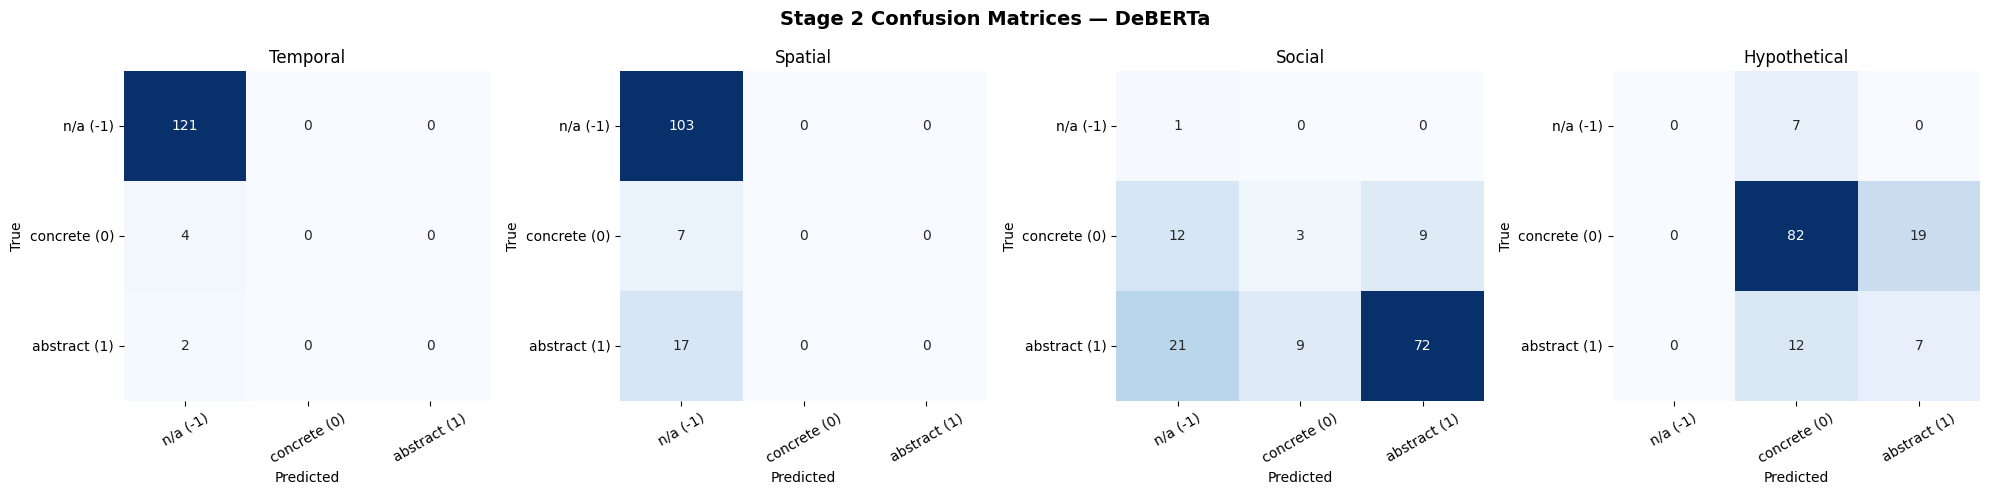

Saved to /content/drive/MyDrive/figures/cm_deberta.pdf


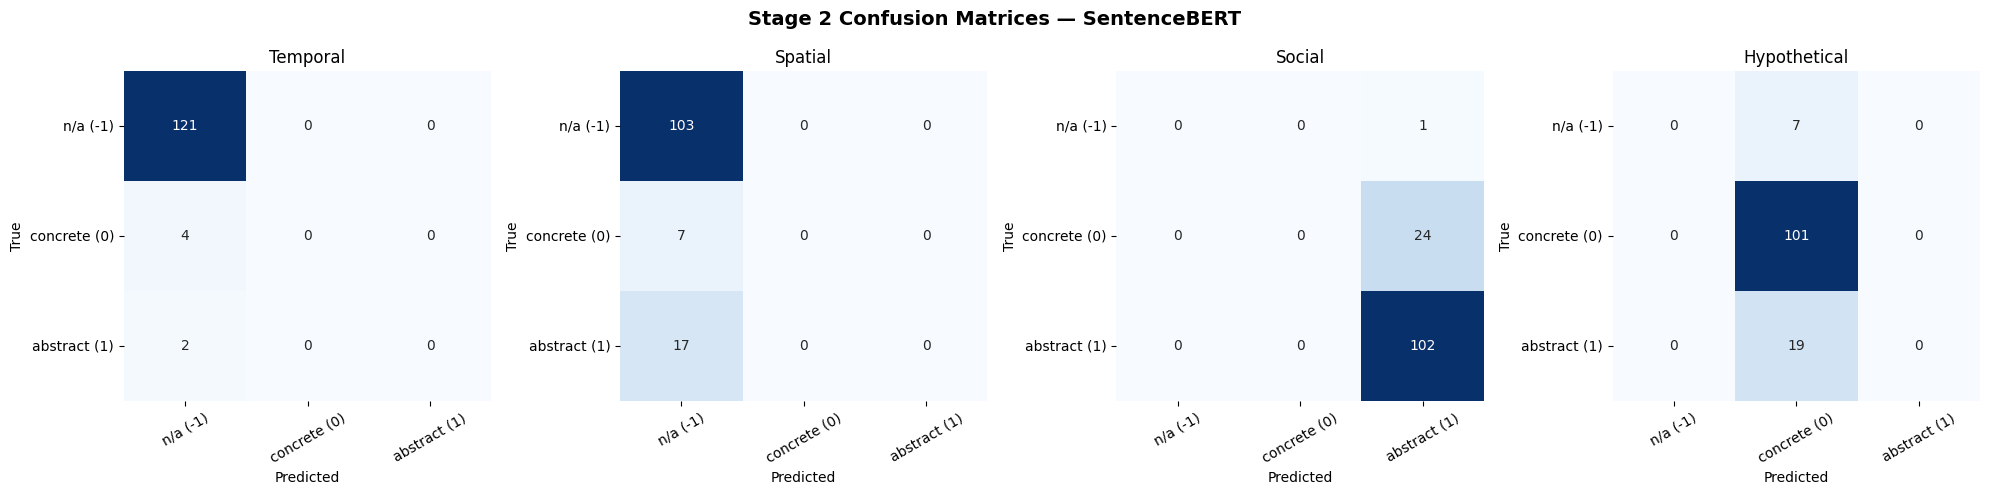

Saved to /content/drive/MyDrive/figures/cm_sbert.pdf


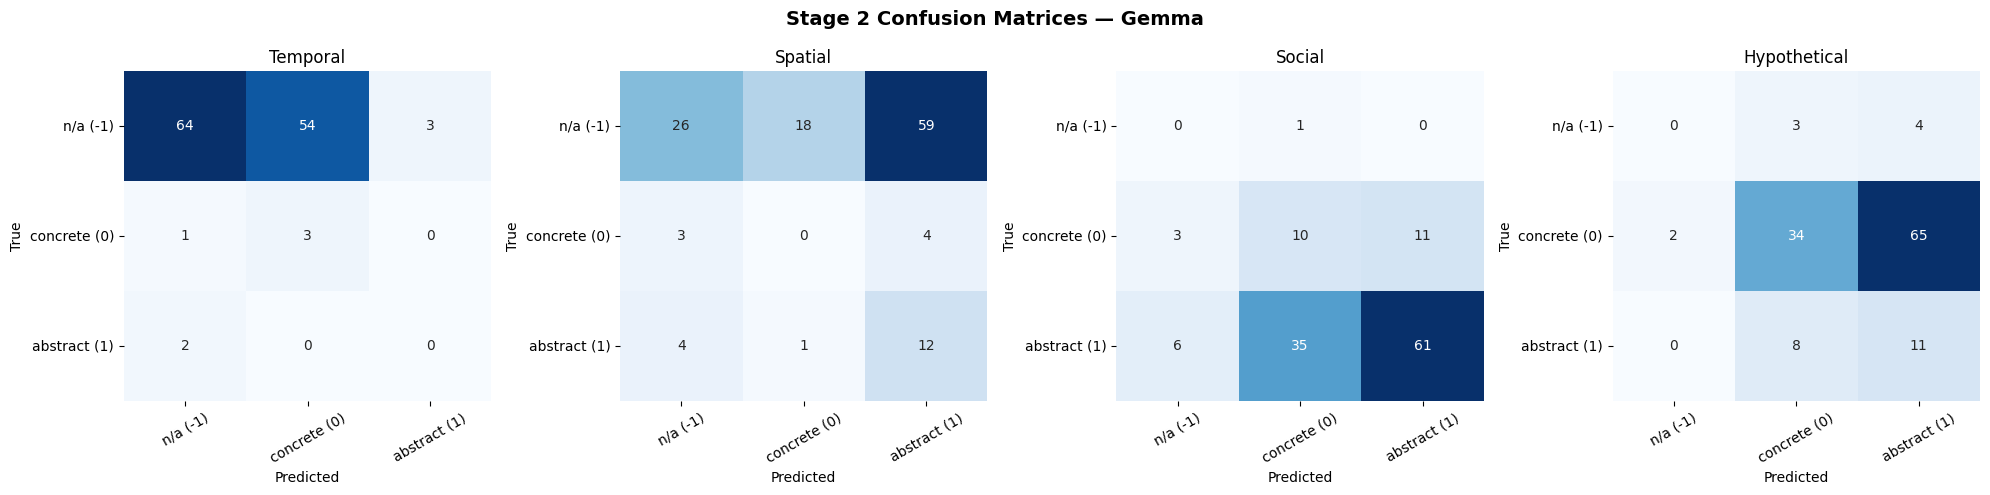

Saved to /content/drive/MyDrive/figures/cm_gemma.pdf


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os

# ── Paths ──────────────────────────────────────────────────
CHECKPOINT_DIR = '/content/drive/MyDrive/checkpoints'
GEMMA_DIR      = '/content/drive/MyDrive/gemma_results'
FIG_DIR        = '/content/drive/MyDrive/figures'
os.makedirs(FIG_DIR, exist_ok=True)

DIMENSIONS = ['temporal', 'spatial', 'social', 'hypothetical']
DIM_LABELS = ['n/a (-1)', 'concrete (0)', 'abstract (1)']

# ── Load predictions ───────────────────────────────────────
def load_json(path):
    with open(path) as f:
        return json.load(f)

# BERT models
deberta_sal  = load_json(os.path.join(CHECKPOINT_DIR, 'salience_predictions_test_deberta.json'))
deberta_dim  = load_json(os.path.join(CHECKPOINT_DIR, 'dimension_predictions_test_deberta.json'))
sbert_sal    = load_json(os.path.join(CHECKPOINT_DIR, 'salience_predictions_test_sbert.json'))
sbert_dim    = load_json(os.path.join(CHECKPOINT_DIR, 'dimension_predictions_test_sbert.json'))

# Gemma
gemma_sal    = load_json(os.path.join(GEMMA_DIR, 'salience_predictions_test.json'))
gemma_dim    = load_json(os.path.join(GEMMA_DIR, 'dimension_predictions_test.json'))

# ── Stage 1: print TP, TN, FP, FN ─────────────────────────
def print_salience_stats(results, model_name):
    if isinstance(results[0], dict) and 'true' in results[0]:
        # BERT format: list of {'true': int, 'pred': int}
        true  = [r['true'] for r in results]
        pred  = [r['pred'] for r in results]
    else:
        # Gemma format: list of {'salient': bool, 'pred': bool, ...}
        true  = [int(r['true']) for r in results]
        pred  = [int(r['pred']) for r in results]

    cm = confusion_matrix(true, pred)
    tn, fp, fn, tp = cm.ravel()
    print(f'{model_name}: TP={tp}, TN={tn}, FP={fp}, FN={fn}')

print('── Stage 1: Salience ──')
print_salience_stats(deberta_sal, 'DeBERTa')
print_salience_stats(sbert_sal,   'SentenceBERT')
print_salience_stats(gemma_sal,   'Gemma')

# ── Stage 2: Confusion matrices ────────────────────────────
def plot_confusion_matrices(dim_results, model_name, save_path, is_gemma=False):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f'Stage 2 Confusion Matrices — {model_name}', fontsize=14, fontweight='bold')

    for ax, dim in zip(axes, DIMENSIONS):
        if is_gemma:
            # Gemma format: list of {'true': {dim: val}, 'pred': {dim: val}}
            LABEL_MAP = {-1: 0, 0: 1, 1: 2}
            true = [LABEL_MAP.get(r['true'][dim], 0) for r in dim_results]
            pred = [LABEL_MAP.get(r['pred'][dim], 0) for r in dim_results]
        else:
            # BERT format: {'temporal': {'true': [...], 'pred': [...]}, ...}
            true = dim_results[dim]['true']
            pred = dim_results[dim]['pred']

        cm = confusion_matrix(true, pred, labels=[0, 1, 2])
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=DIM_LABELS,
            yticklabels=DIM_LABELS,
            ax=ax, cbar=False,
        )
        ax.set_title(dim.capitalize(), fontsize=12)
        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('True', fontsize=10)
        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {save_path}')

# Generate and save figures
plot_confusion_matrices(deberta_dim, 'DeBERTa',      os.path.join(FIG_DIR, 'cm_deberta.pdf'))
plot_confusion_matrices(sbert_dim,   'SentenceBERT', os.path.join(FIG_DIR, 'cm_sbert.pdf'))
plot_confusion_matrices(gemma_dim,   'Gemma',        os.path.join(FIG_DIR, 'cm_gemma.pdf'), is_gemma=True)